# Simple Linear Regression on Housing Prices

Dataset used: California Housing dataset

### Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing

In [2]:
housing= fetch_california_housing()
df=pd.DataFrame(housing.data, columns=housing.feature_names)
df["PRICE"]=housing.target
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PRICE
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
print('Shape',df.shape,'\n')
df.info()
df.isnull().sum()
df.describe()

Shape (20640, 9) 

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   PRICE       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PRICE
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


Observation: Max AveRooms, Max AveOccup, Max population and Max Price are unusual

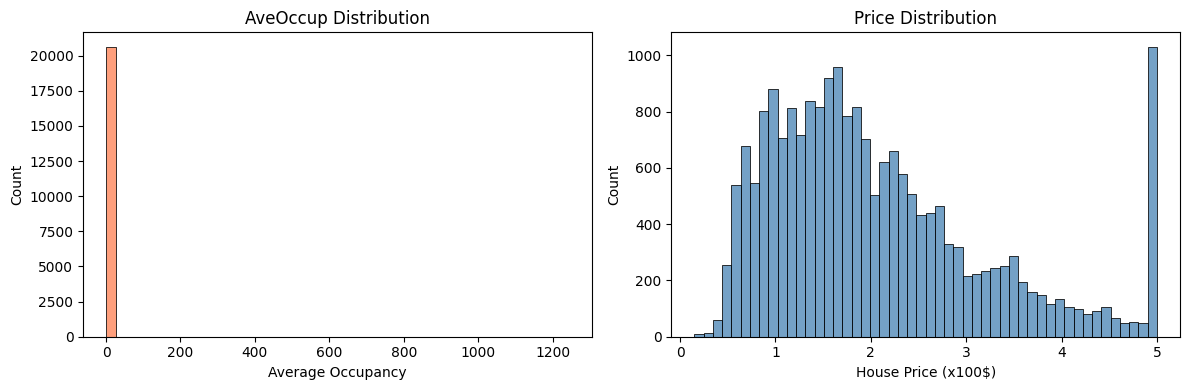

In [11]:
fig,axes= plt.subplots(1,2, figsize=(12,4))
sns.histplot(df["AveOccup"], ax = axes[0], color= 'coral',bins=50)
axes[0].set_title("AveOccup Distribution")
axes[0].set_xlabel("Average Occupancy")

sns.histplot(df["PRICE"], ax = axes[1],color = "steelblue",bins=50)
axes[1].set_title("Price Distribution")
axes[1].set_xlabel("House Price (x100$)")
plt.tight_layout()
plt.show()

In [17]:
# Reasoning the unusual AveOccup Graph
# How many households actually have occupancy > 20?
extreme = df[df['AveOccup'] > 20]
normal  = df[df['AveOccup'] <= 20]

print(f"Total rows            : {len(df)}")
print(f"Rows with AveOccup > 20 : {len(extreme)}")
print(f"Rows with AveOccup ≤ 20 : {len(normal)}")
print(f"Extreme values %      : {round(len(extreme)/len(df)*100, 2)}%")

Total rows            : 20640
Rows with AveOccup > 20 : 10
Rows with AveOccup ≤ 20 : 20630
Extreme values %      : 0.05%


#### Cleaning Data Sets
Removing outliers

In [16]:
def remove_outlier(dataframe, column):
    q1=dataframe[column].quantile(0.25)
    q3=dataframe[column].quantile(0.75)
    IQR=q3-q1
    lower= q1-1.5*IQR
    upper= q3+1.5*IQR
    return dataframe[(dataframe[column]>=lower) & (dataframe[column]<=upper)]
df_clean= remove_outlier(df, "AveOccup")
df_clean = remove_outlier(df_clean, "AveRooms")
print("Original Shape ", df.shape)
print("Cleaned shape:",df_clean.shape)
print("Rows Removed:", df.shape[0] - df_clean.shape[0])

Original Shape  (20640, 9)
Cleaned shape: (19430, 9)
Rows Removed: 1210


#### Graphs after Cleaning

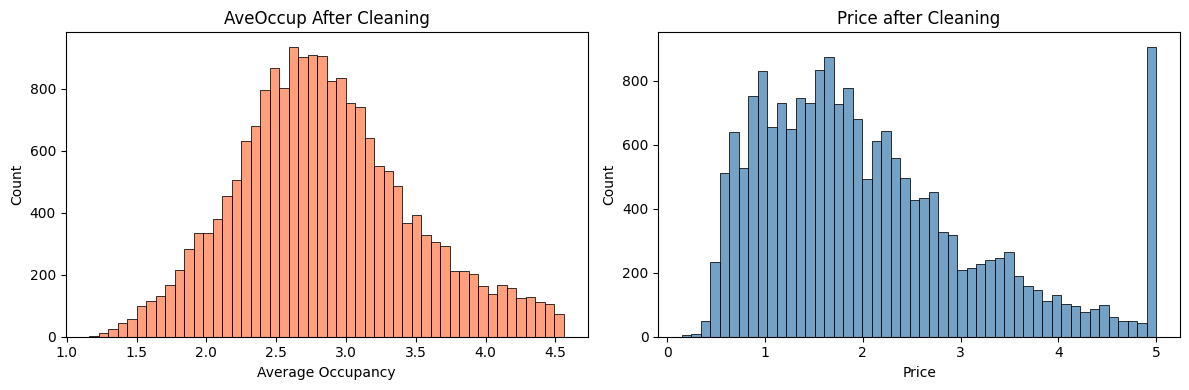

In [22]:
fig, axes = plt.subplots(1,2,figsize=(12,4))
sns.histplot(df_clean['AveOccup'], ax=axes[0], color= 'coral', bins=50)
axes[0].set_title("AveOccup After Cleaning")
axes[0].set_xlabel('Average Occupancy')
sns.histplot(df_clean['PRICE'],ax = axes[1], color= "steelblue", bins=50)
axes[1].set_title('Price after Cleaning')
axes[1].set_xlabel("Price")
plt.tight_layout()
plt.show()

In [23]:
df_clean=df_clean.reset_index(drop=True)
print('Index reset, New shape ', df_clean.shape)

Index reset, New shape  (19430, 9)


#### Exploratory Data Analysis

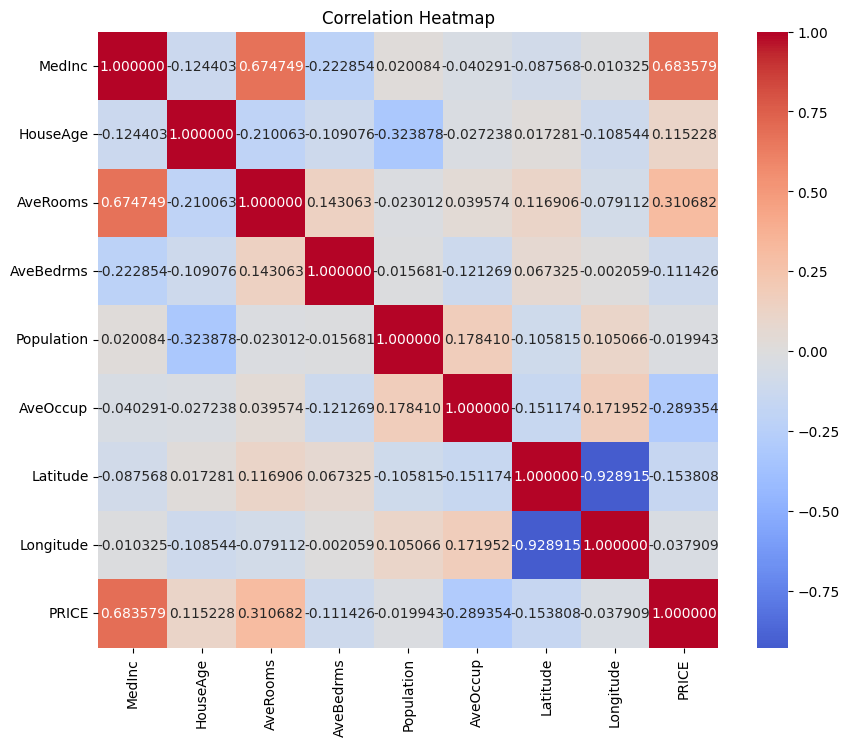

In [24]:
# Correlation
plt.figure(figsize=(10,8))
sns.heatmap(df_clean.corr(),annot=True, fmt='2f', cmap='coolwarm', center=0)
plt.title("Correlation Heatmap")
plt.show()

In [27]:
corr_price= df_clean.corr()['PRICE'].sort_values(ascending=False)
print(corr_price)

PRICE         1.000000
MedInc        0.683579
AveRooms      0.310682
HouseAge      0.115228
Population   -0.019943
Longitude    -0.037909
AveBedrms    -0.111426
Latitude     -0.153808
AveOccup     -0.289354
Name: PRICE, dtype: float64


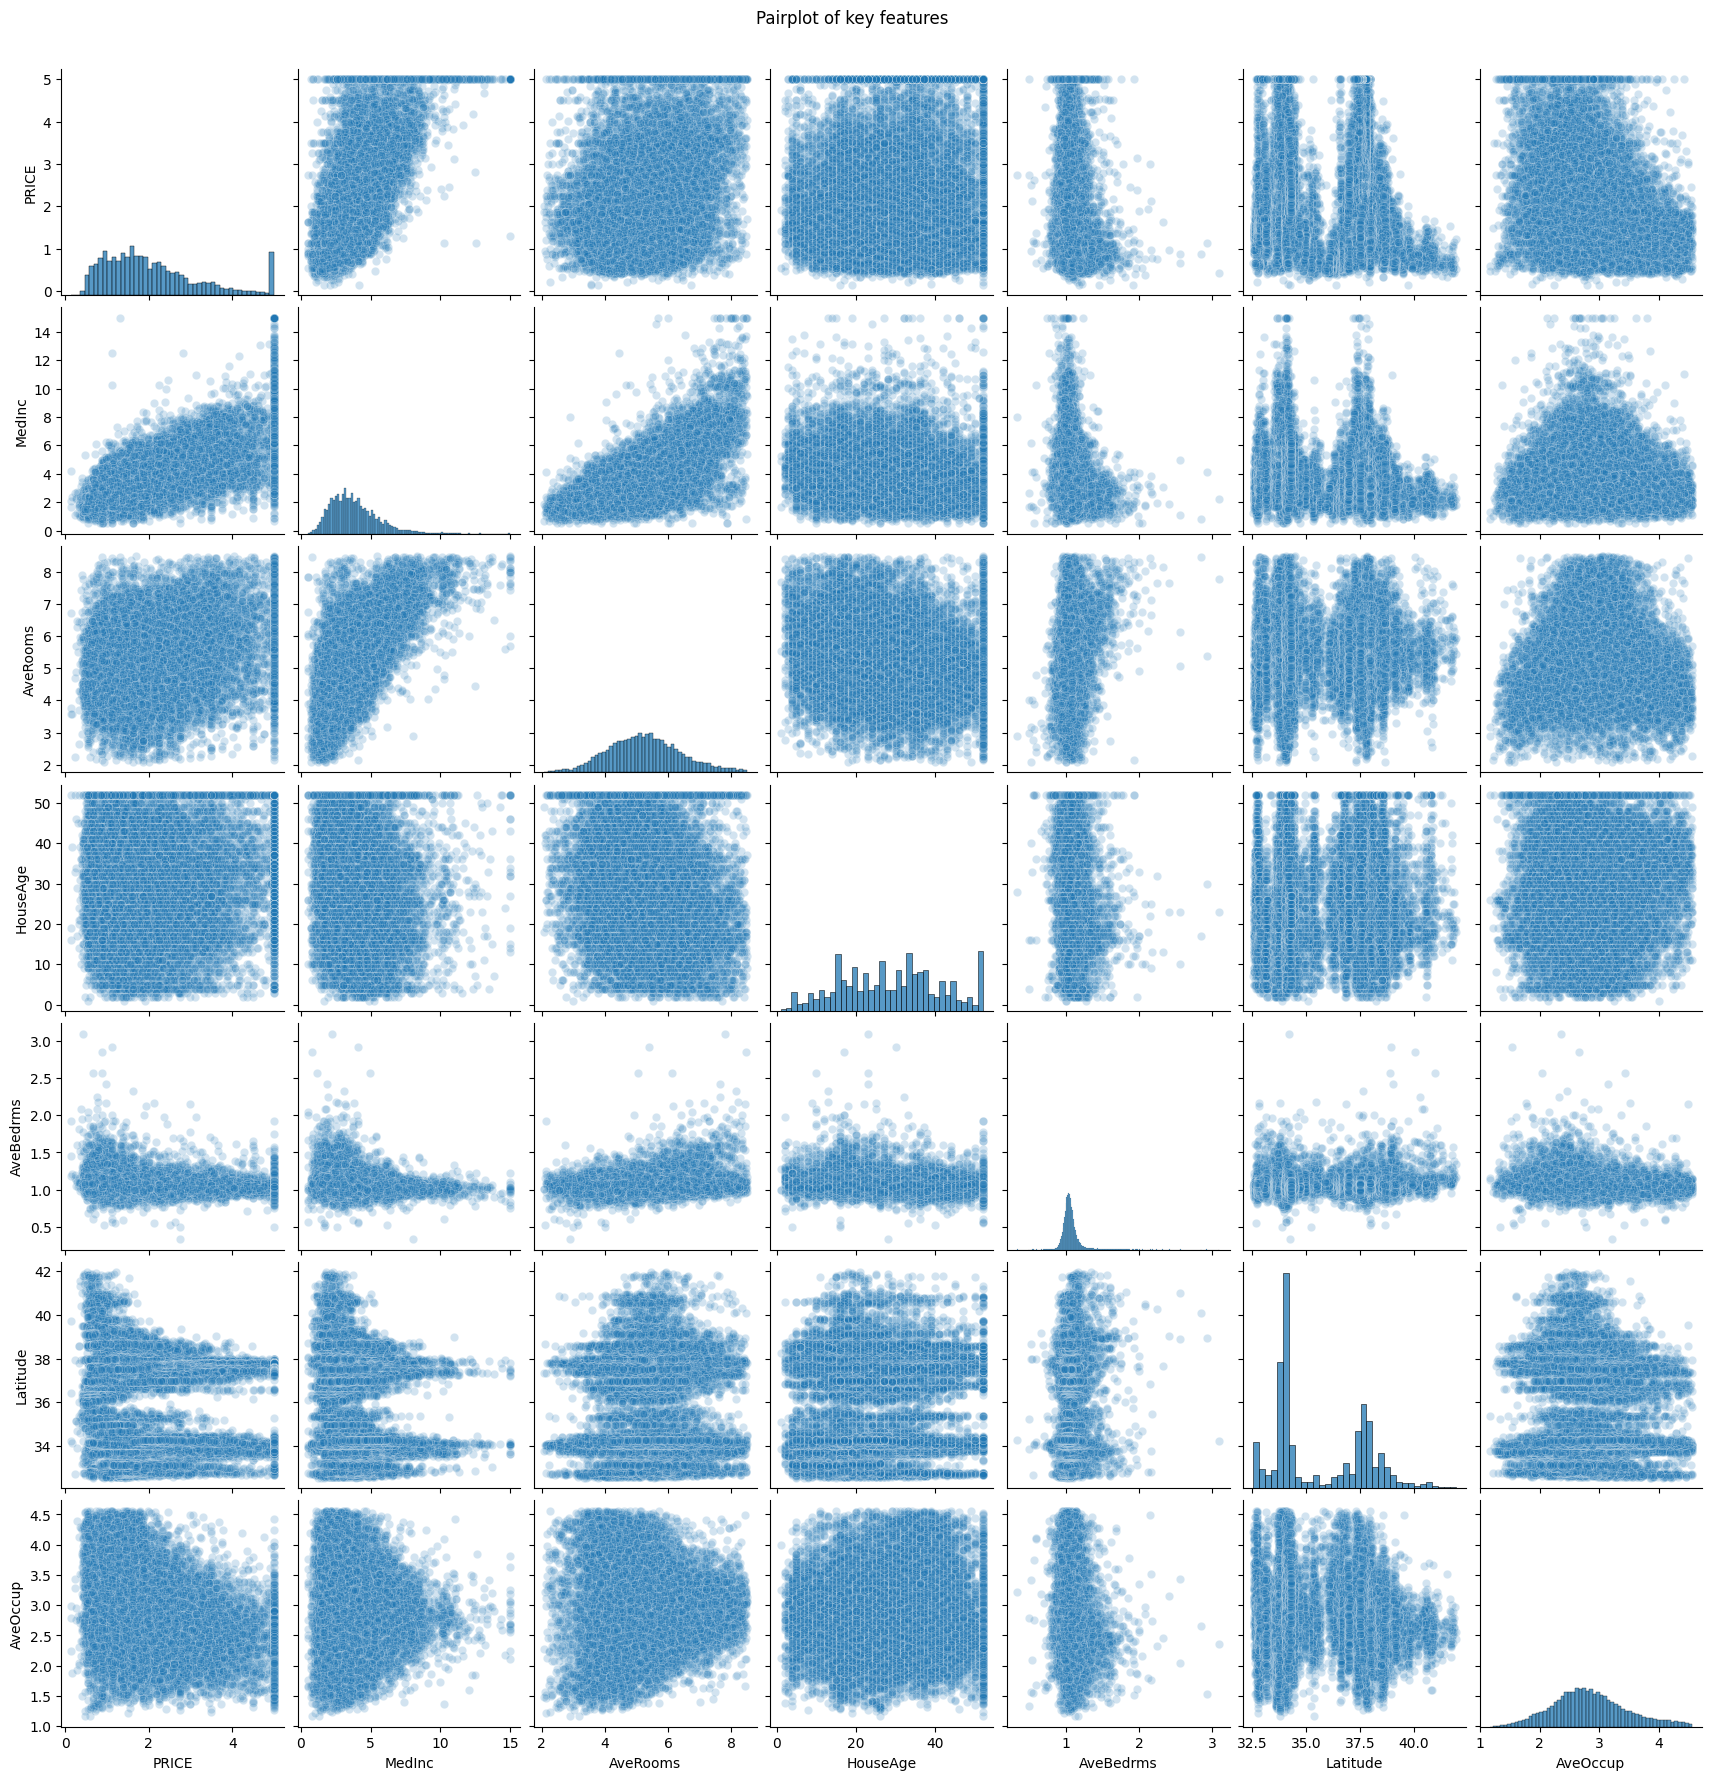

In [66]:
features = corr_price[abs(corr_price) > 0.1].index.tolist()
#features.remove('PRICE')
sns.pairplot(df_clean[features],plot_kws={'alpha':0.2}, diag_kind= 'hist')
plt.suptitle('Pairplot of key features', y=1.02)
plt.show()

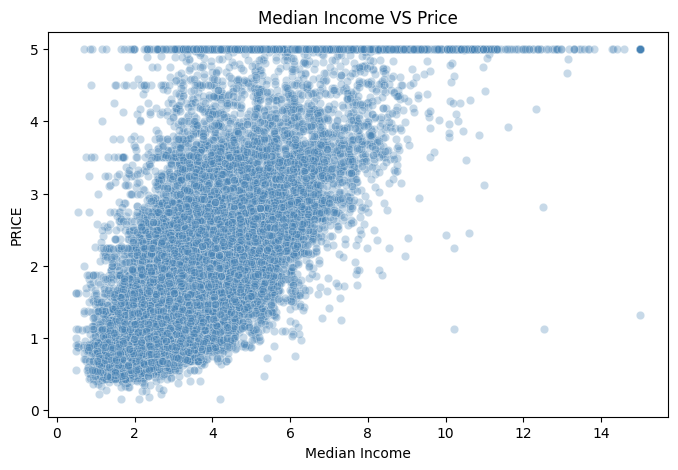

In [29]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df_clean['MedInc'], y= df_clean['PRICE'], alpha=0.3, color='steelblue')
plt.title("Median Income VS Price")
plt.xlabel("Median Income")
plt.ylabel("PRICE")
plt.show()

Observation:
1. MedInc is the strongest predictor of PRICE   
2. AveOccup has a negative correlation with PRICE   
3. HouseAge has very weak relationship with PRICE  
4. AveRooms and MedInc are correlated with each other  
5. PRICE has artificial cap at 5.0  
6. MedInc is right skewed  
7. AveRooms distribution is clean after outlier removal  

#### Preprocessing the Data

In [67]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
X=df_clean[features].drop('PRICE', axis=1)
y= df_clean[features]['PRICE']
print('features:',X.columns.tolist())

features: ['MedInc', 'AveRooms', 'HouseAge', 'AveBedrms', 'Latitude', 'AveOccup']


In [68]:
X_train, X_test, y_train, y_test= train_test_split(X,y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Scaled mean",X_train_scaled.mean().round(4) , "and std:",X_train_scaled.std().round(4))

Scaled mean -0.0 and std: 1.0


In [69]:
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (15544, 6)
X_test shape : (3886, 6)
y_train shape: (15544,)
y_test shape : (3886,)


In [70]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled, y_train)

print("Model Trained!!!")
print(f"\nIntercept: {round(model.intercept_, 4)}")
print("\nFeature Weights:")
for feature, weight in zip(X.columns, model.coef_):
    print(f"  {feature:12} → {weight:.4f}")

Model Trained!!!

Intercept: 2.0746

Feature Weights:
  MedInc       → 0.9923
  AveRooms     → -0.2708
  HouseAge     → 0.2068
  AveBedrms    → 0.1285
  Latitude     → -0.1123
  AveOccup     → -0.2726


Intercept means price at features=0  
and positive means feature pushes the price up  
and negative means feature pushes the price down

In [72]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

y_pred = model.predict(X_test_scaled)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print("Model Evaluation:")
print("─" * 40)
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")

Model Evaluation:
────────────────────────────────────────
MSE  : 0.4868
RMSE : 0.6977
MAE  : 0.5116
R²   : 0.6329


Observation:  
The linear regression model achieved an R² of 0.69,  
explaining 69% of the variance in house prices,  
with an average prediction error of approximately $47,130 (MAE) on unseen test data.

In [73]:
# Overfitting check
train_pred = model.predict(X_train_scaled)
train_r2   = r2_score(y_train, train_pred)
test_r2    = r2_score(y_test, y_pred)

print("\nOverfitting Check:")
print("─" * 40)
print(f"Training R²  : {train_r2:.4f}")
print(f"Testing  R²  : {test_r2:.4f}")
print(f"Difference   : {abs(train_r2 - test_r2):.4f}")

if abs(train_r2 - test_r2) < 0.05:
    print("Model generalises well ")
else:
    print("Possible overfitting ")


Overfitting Check:
────────────────────────────────────────
Training R²  : 0.6115
Testing  R²  : 0.6329
Difference   : 0.0214
Model generalises well 


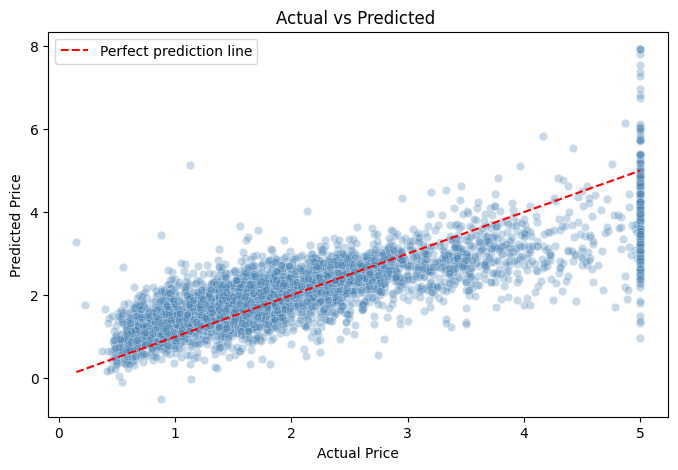

In [83]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test, y=y_pred, 
                alpha=0.3, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linewidth=1.5,
         linestyle='--', label='Perfect prediction line')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted ')
plt.legend()
plt.show()